# Chương 2: Tổng quan dữ liệu đầu vào
Notebook này cung cấp các phân tích Khám phá Dữ liệu (EDA) chi tiết để trực quan hóa dữ liệu và tóm tắt phương pháp tiền xử lý dữ liệu cho cả Dữ liệu Văn bản (Text) và Hình ảnh (Image).
Các số liệu và biểu đồ ở đây được thiết kế sát với yêu cầu của Báo cáo cuối kỳ.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Đảm bảo thư mục lưu ảnh tồn tại
os.makedirs('../model_report/graphics', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'


## 1. Dữ liệu Văn bản (Text)
### 1.1 Phân bố nhãn Cảm xúc và Spam
Phân tích tỷ lệ các nhãn Cảm xúc (Tích cực, Tiêu cực, Trung lập) và nhãn Spam trong tập dữ liệu. Việc hiểu rõ mức độ mất cân bằng lớp là cơ sở để chọn phương pháp huấn luyện phù hợp (ví dụ: dùng class weights).


Tổng số mẫu văn bản: 25292


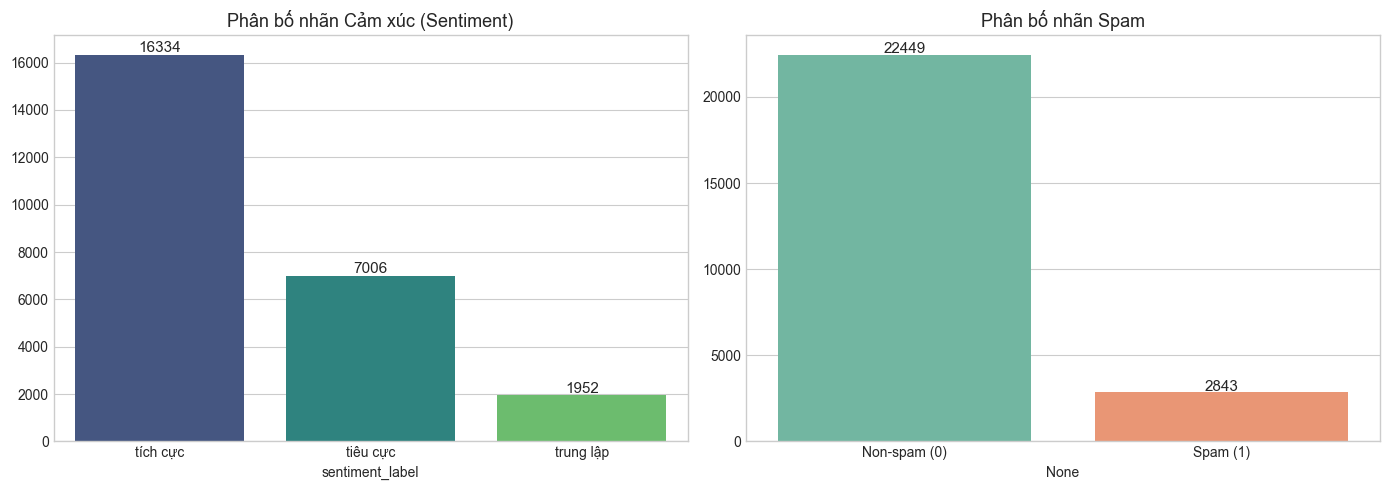

In [9]:
# Đọc dữ liệu
text_df = pd.read_csv('../data/processed/spam_labeled_text.csv')
print(f"Tổng số mẫu văn bản: {len(text_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Sentiment
sentiment_counts = text_df['sentiment_label'].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False, ax=axes[0])
axes[0].set_title('Phân bố nhãn Cảm xúc (Sentiment)', fontsize=13)
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=11)

# Biểu đồ Spam
spam_counts = text_df['is_spam'].value_counts()
spam_counts.index = ['Non-spam (0)', 'Spam (1)']
sns.barplot(x=spam_counts.index, y=spam_counts.values, palette='Set2', hue=spam_counts.index, legend=False, ax=axes[1])
axes[1].set_title('Phân bố nhãn Spam', fontsize=13)
for i, v in enumerate(spam_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../model_report/graphics/text_label_distributions.png', dpi=300)
plt.show()


### 1.2 Phân bố Độ dài Văn bản
Đánh giá độ dài bình luận (tính bằng số lượng từ) để hiểu rõ hơn hành vi của người dùng. Khách hàng không hài lòng thường có xu hướng viết dài hơn để mô tả lỗi.


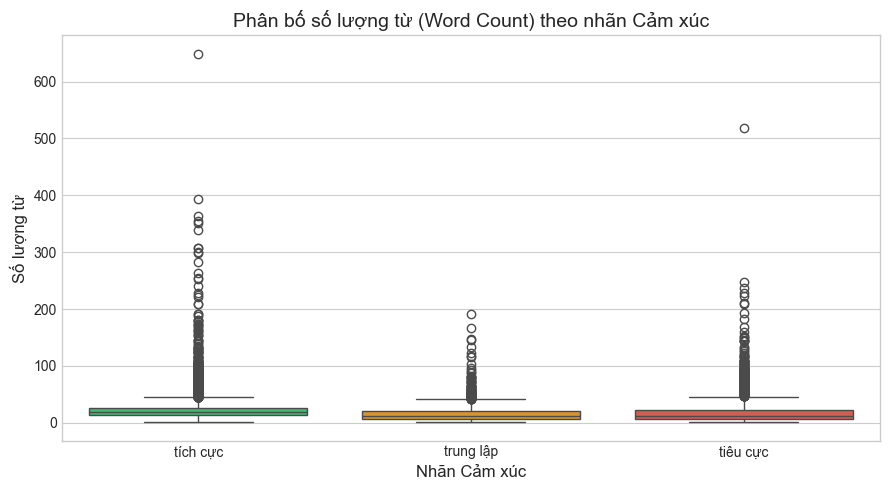

                   count   mean    std  min   25%   50%   75%    max
sentiment_label                                                     
tiêu cực          7006.0  17.65  19.10  1.0   6.0  12.0  22.0  518.0
trung lập         1952.0  15.48  15.51  1.0   6.0  11.0  20.0  192.0
tích cực         16334.0  21.76  18.56  1.0  13.0  19.0  26.0  649.0


In [10]:
text_df['word_count'] = text_df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=text_df, 
    x='sentiment_label', 
    y='word_count', 
    hue='sentiment_label', 
    palette={"tích cực": "#2ECC71", "trung lập": "#F39C12", "tiêu cực": "#E74C3C"},
    order=["tích cực", "trung lập", "tiêu cực"],
    legend=False
)
plt.title("Phân bố số lượng từ (Word Count) theo nhãn Cảm xúc", fontsize=14)
plt.xlabel("Nhãn Cảm xúc", fontsize=12)
plt.ylabel("Số lượng từ", fontsize=12)
plt.tight_layout()
plt.savefig('../model_report/graphics/text_word_count_boxplot.png', dpi=300)
plt.show()

# In thống kê cơ bản
print(text_df.groupby('sentiment_label')['word_count'].describe().round(2))


## 2. Dữ liệu Hình ảnh (Image)
### 2.1 Phân bố các lớp ảnh
Dữ liệu hình ảnh được gán nhãn thành 4 lớp độc lập: `intact` (nguyên vẹn), `damaged` (hư hỏng), `wrong_item` (giao sai hàng) và `irrelevant` (không liên quan).


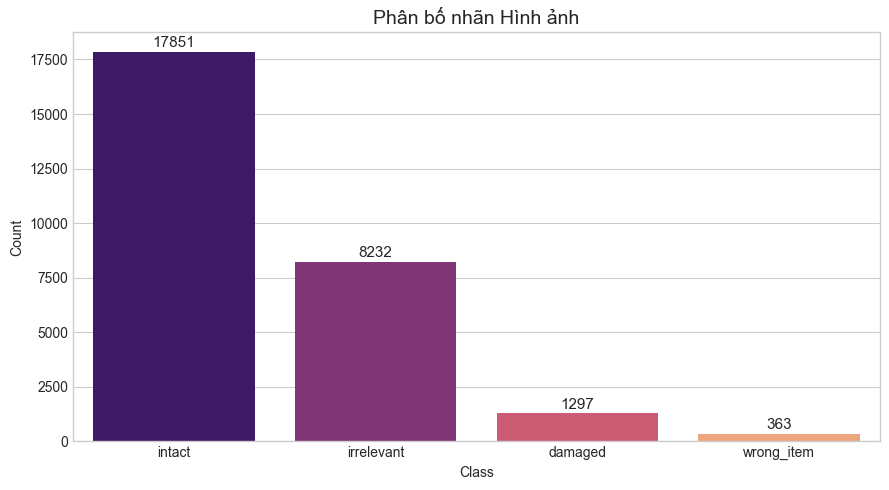

In [11]:
image_dir = '../image_labeling/data/labeled'
classes = [d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]
image_counts = {c: len(os.listdir(os.path.join(image_dir, c))) for c in classes}

image_df = pd.DataFrame(list(image_counts.items()), columns=['Class', 'Count']).sort_values(by='Count', ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(data=image_df, x='Class', y='Count', palette='magma', hue='Class', legend=False)
plt.title('Phân bố nhãn Hình ảnh', fontsize=14)
for i, v in enumerate(image_df['Count']):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../model_report/graphics/image_distribution.png', dpi=300)
plt.show()


### 2.2 Chiến lược Tiền xử lý Ảnh (On-the-fly Transforms)

Đối với dữ liệu hình ảnh, thay vì xử lý (Resize, Normalize, xoay lật...) rồi lưu hàng chục ngàn bức ảnh mới ra ổ cứng, hệ thống tích hợp toàn bộ pipeline tiền xử lý vào **quá trình nạp dữ liệu (On-the-fly Transforms)** bằng công cụ `Albumentations` trong PyTorch `DataLoader`.

**Lý do lựa chọn phương pháp này:**
1. **Tối ưu hóa tài nguyên:** Không làm phình to dung lượng ổ cứng để lưu trữ các biến thể của ảnh.
2. **Ngăn chặn Overfitting (Quá khớp):** Ở mỗi Epoch trong quá trình huấn luyện, mô hình sẽ được tiếp xúc với một biến thể ngẫu nhiên khác nhau của cùng một bức ảnh (ví dụ: epoch 1 xoay 10 độ, epoch 2 lật ngang, epoch 3 thêm nhiễu hạt). Điều này làm tăng độ đa dạng dữ liệu một cách linh hoạt, giúp mô hình học được các đặc trưng bất biến tốt hơn so với việc chỉ học trên một bộ ảnh tĩnh duy nhất.
3. **Tiêu chuẩn thực hành (Best Practice):** Cấu trúc Custom Dataset kết hợp Transform trực tiếp là kiến trúc tiêu chuẩn và tối ưu nhất cho các luồng huấn luyện Deep Learning hiện đại.

Dưới đây là một ví dụ minh họa sự biến đổi của ảnh trước và sau khi đi qua pipeline Augmentation:


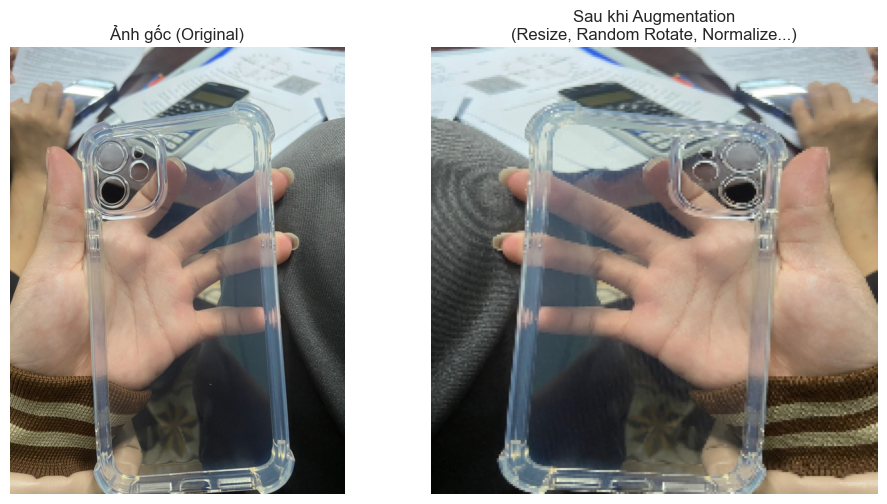

In [12]:
import sys
sys.path.append('../')
from ai_engine.image_processing.augmentation.transforms import get_defect_transforms

# Chọn thử 1 ảnh bị lỗi (damaged) để minh hoạ
damaged_dir = os.path.join(image_dir, 'damaged')
sample_img_name = os.listdir(damaged_dir)[0]
sample_img_path = os.path.join(damaged_dir, sample_img_name)

# Đọc ảnh gốc bằng OpenCV
img_bgr = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Áp dụng Augmentation (Dùng pipeline lấy từ mã nguồn của nhóm)
transform_pipeline = get_defect_transforms()
augmented = transform_pipeline(image=img_rgb)['image']
img_aug_np = augmented.permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_aug_display = np.clip(std * img_aug_np + mean, 0, 1)

# Vẽ minh hoạ
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Ảnh gốc (Original)")
axes[0].axis('off')

axes[1].imshow(img_aug_display)
axes[1].set_title("Sau khi Augmentation\n(Resize, Random Rotate, Normalize...)")
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../model_report/graphics/augmentation_demo.png', dpi=300)
plt.show()


## 3. Phân chia tập dữ liệu (Train/Val/Test Split)
Vì dữ liệu bị mất cân bằng lớp nặng (nhãn tích cực và intact chiếm ưu thế lớn), chúng ta sử dụng phương pháp **Stratified Split** với tỷ lệ **80% Train, 10% Validation, 10% Test**. 
Cơ chế Stratified đảm bảo tỷ lệ các lớp trong từng tập con hoàn toàn đồng nhất với phân bố trong tập dữ liệu gốc, giúp quá trình huấn luyện và đánh giá mô hình không bị thiên lệch.


In [13]:
# Mô phỏng chia tập dữ liệu Text (Sentiment)
X = text_df.index.values
y = text_df['sentiment_label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

split_df = pd.DataFrame({
    'Tập dữ liệu': ['Train (80%)', 'Validation (10%)', 'Test (10%)'],
    'Tổng số mẫu': [len(y_train), len(y_val), len(y_test)],
    'Tích cực': [np.sum(y_train == 'tích cực'), np.sum(y_val == 'tích cực'), np.sum(y_test == 'tích cực')],
    'Tiêu cực': [np.sum(y_train == 'tiêu cực'), np.sum(y_val == 'tiêu cực'), np.sum(y_test == 'tiêu cực')],
    'Trung lập': [np.sum(y_train == 'trung lập'), np.sum(y_val == 'trung lập'), np.sum(y_test == 'trung lập')]
})
print("Bảng phân chia tập dữ liệu Văn bản (Sentiment):")
print(split_df.to_string(index=False))


Bảng phân chia tập dữ liệu Văn bản (Sentiment):
     Tập dữ liệu  Tổng số mẫu  Tích cực  Tiêu cực  Trung lập
     Train (80%)        20233     13067      5605       1561
Validation (10%)         2529      1633       700        196
      Test (10%)         2530      1634       701        195
